## Notebook to learn to play with tif images

In [1]:
import sys
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt

import experiment_settings
import build_model
import train_model
import build_data
import methods

import tensorflow as tf


In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")

# tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
print(tf.config.list_physical_devices("GPU"))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GET SETTINGS
EXP_NAME = "exp0"
settings = experiment_settings.get_settings(EXP_NAME)
settings["mode"] = "training"

# SET RANDOM SEEDS
np.random.seed(settings["rng_seed"])
random.seed(settings["rng_seed"])
tf.random.set_seed(settings["rng_seed"])


In [6]:
imp.reload(build_data)
imp.reload(methods)

tags_train, tags_val = build_data.get_tags(settings)

(array([], dtype=object), array([], dtype=object), array([], dtype=object), [])

In [4]:
# LOAD THE DATA
imp.reload(build_data)
imp.reload(methods)

tags_train, tags_val = build_data.get_tags(settings)

tfds_train = build_data.build_tf_dataset(settings, tags_train, settings["batch_size"])
tfds_val = build_data.build_tf_dataset(settings, tags_val, settings["batch_size"])

batch_shape = np.shape(next(tfds_val.as_numpy_iterator())[0])
print(f"{batch_shape = }")


-7.0 -6.0 106.0 107.0
106.0 -7.0
33396 33766 106124 106494
Window(col_off=106124, row_off=33396, width=371, height=371)
133407
edge_width = 0.03099135
107.0 -7.0
33396 33766 106495 106866
Window(col_off=106495, row_off=33396, width=372, height=371)
125942
edge_width = 0.03099135
106.0 -6.0
33025 33395 106124 106494
Window(col_off=106124, row_off=33025, width=371, height=371)
17797
edge_width = 0.03099135
107.0 -6.0
33025 33395 106495 106866
Window(col_off=106495, row_off=33025, width=372, height=371)
3980
edge_width = 0.03099135
len(tagyear_train) = 0, len(tagyear_val) = 0
Metal device set to: Apple M1 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB



/Users/eabarnes/GoogleDrive/WORK/RESEARCH/2023/ml_hfi_multiyear/build_data.py:177: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sample_lats, sample_lons, sample_years = np.asarray(sample_lats), np.asarray(sample_lons), np.asarray(sample_years)


InvalidArgumentError: {{function_node __wrapped__ShuffleDatasetV3_device_/job:localhost/replica:0/task:0/device:CPU:0}} buffer_size must be greater than zero. [Op:ShuffleDatasetV3]

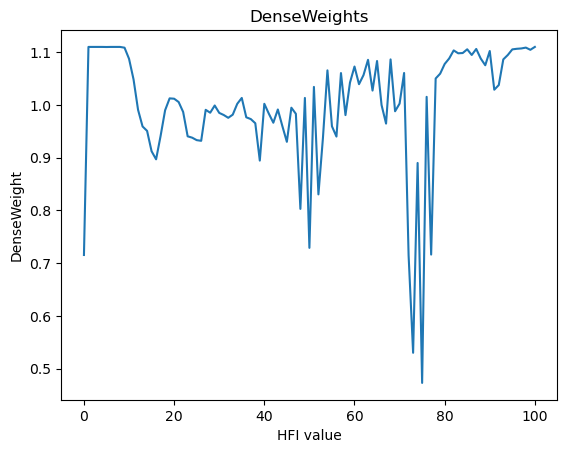

In [ ]:
plt.title("DenseWeights")
plt.plot(np.arange(0, 101, 1), denseweight_dist)
plt.xlabel("HFI value")
plt.ylabel("DenseWeight")
plt.show()

In [ ]:
# TRAIN THE MODEL
imp.reload(build_model)
imp.reload(train_model)
imp.reload(methods)

tf.keras.backend.clear_session()
model = build_model.build_model(settings, input_shape=batch_shape[1:])

settings["mode"] = "training"
model, fit_summary, history, settings = train_model.train_model(
    settings, model, tfds_train, tfds_val, denseweight_dist
)
fit_summary

Epoch 1/1000
 53/200 [======>.......................] - ETA: 26s - loss: 23.0057 - mae: 19.7283

KeyboardInterrupt: 

In [ ]:
print("training complete.")


training complete.
